# Importing Libraries


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error,r2_score

# Loading Data

In [75]:
data = pd.read_csv("Housing.csv")

# Features without scaling and encoding

In [76]:
X_input = data[['area','bedrooms','bathrooms','stories','parking']]
y_target = data['price']


# Spliting Data

In [77]:
X_train_1,X_test_1,y_train_1,y_test_1 = train_test_split(X_input,y_target,test_size=0.2,random_state=42)

# Training Model

In [78]:
model_1 = LinearRegression()
model_1.fit(X_train_1,y_train_1)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Predecting 

In [79]:
y_pred_1 = model_1.predict(X_test_1)

# Ploting Predicted vs Actual 

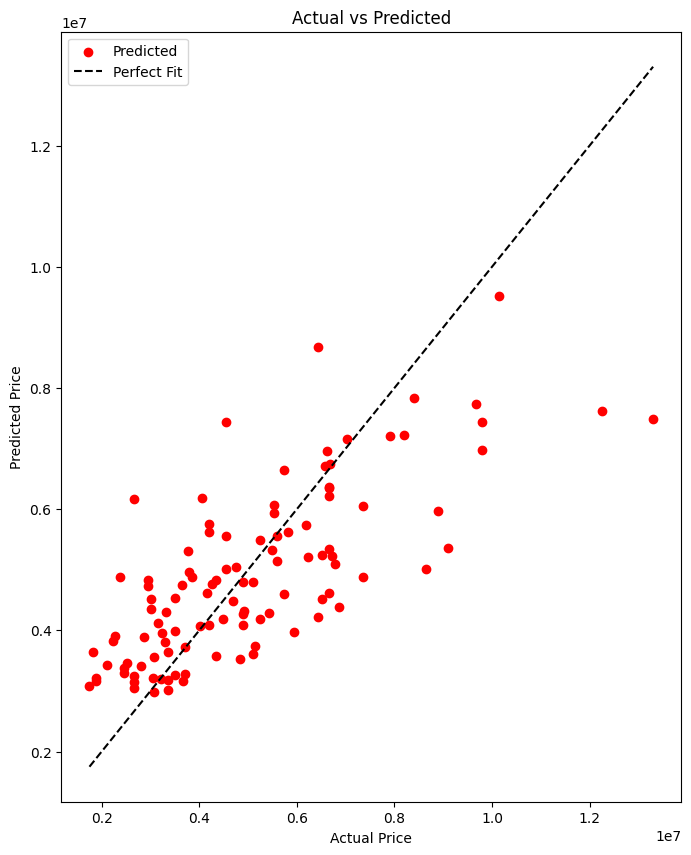

In [80]:
plt.figure(figsize=(8,10))
plt.scatter(y_test_1,y_pred_1,color='red',label='Predicted')
plt.plot([y_target.min(),y_target.max()],[y_target.min(),y_target.max()],'k--',label='Perfect Fit')
plt.title("Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")   
plt.legend()
plt.show()

# MSE and R2_score

In [81]:
mse = mean_squared_error(y_test_1,y_pred_1)
print(f'Mean Squared Error : {mse:.3f}')

r2 = r2_score(y_test_1,y_pred_1)
print(f'R2 Score : {r2:.3f}')


Mean Squared Error : 2292721545725.362
R2 Score : 0.546


## With Encoding and Scaling 

# Yes/No to 0/1

In [82]:
X = data.drop('price',axis=1)
print(X.head(2))

binary_col = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
X[binary_col] = X[binary_col].apply(lambda x:x.map({'yes':1,'no':0}))
X.head(2)

   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,8960,4,4,4,1,0,0,0,1,3,0,furnished


# Encoding Furnishing Status


In [83]:
encoder = OneHotEncoder(drop='first',sparse_output=False)
encoded_status = encoder.fit_transform(X[['furnishingstatus']])
encoded_df = pd.DataFrame(encoded_status,columns=encoder.get_feature_names_out(['furnishingstatus']),index=X.index)

# Droping Original Column and Concatenate with encoded one

In [84]:
X = X.drop('furnishingstatus',axis=1)
X=pd.concat([X,encoded_df],axis=1)
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0.0,0.0
1,8960,4,4,4,1,0,0,0,1,3,0,0.0,0.0
2,9960,3,2,2,1,0,1,0,0,2,1,1.0,0.0
3,7500,4,2,2,1,0,1,0,1,3,1,0.0,0.0
4,7420,4,1,2,1,1,1,0,1,2,0,0.0,0.0
